# Faraday Rotation Results

Simulation results at 10, 30, 50 MHz with and without Faraday rotation.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator, NullFormatter
from lunarsky import Time

# ——— Data ———
RES_DIR = Path("results")
sims = {}
for freq in [10, 30, 50]:
    sims[freq] = dict(np.load(RES_DIR / f"faraday_sim_{freq}mhz.npz"))

times_jd = sims[10]["times_jd"]
times_dt = [Time(jd, format="jd").to_datetime() for jd in times_jd]

# ——— Colors (Paul Tol Bright) ———
BLUE = "#4477AA"
RED = "#EE6677"

# ——— Journal rcParams ———
mpl.rcParams.update({
    "figure.dpi": 200,
    "font.size": 8,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.size": 3.0,
    "ytick.major.size": 3.0,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.size": 1.5,
    "ytick.minor.size": 1.5,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,
})

## Plot 1 — Stokes I, Q, U Waterfall at 30 MHz

Frequency vs time for no-FR (top) and FR (bottom). Zoom-bin resolution.

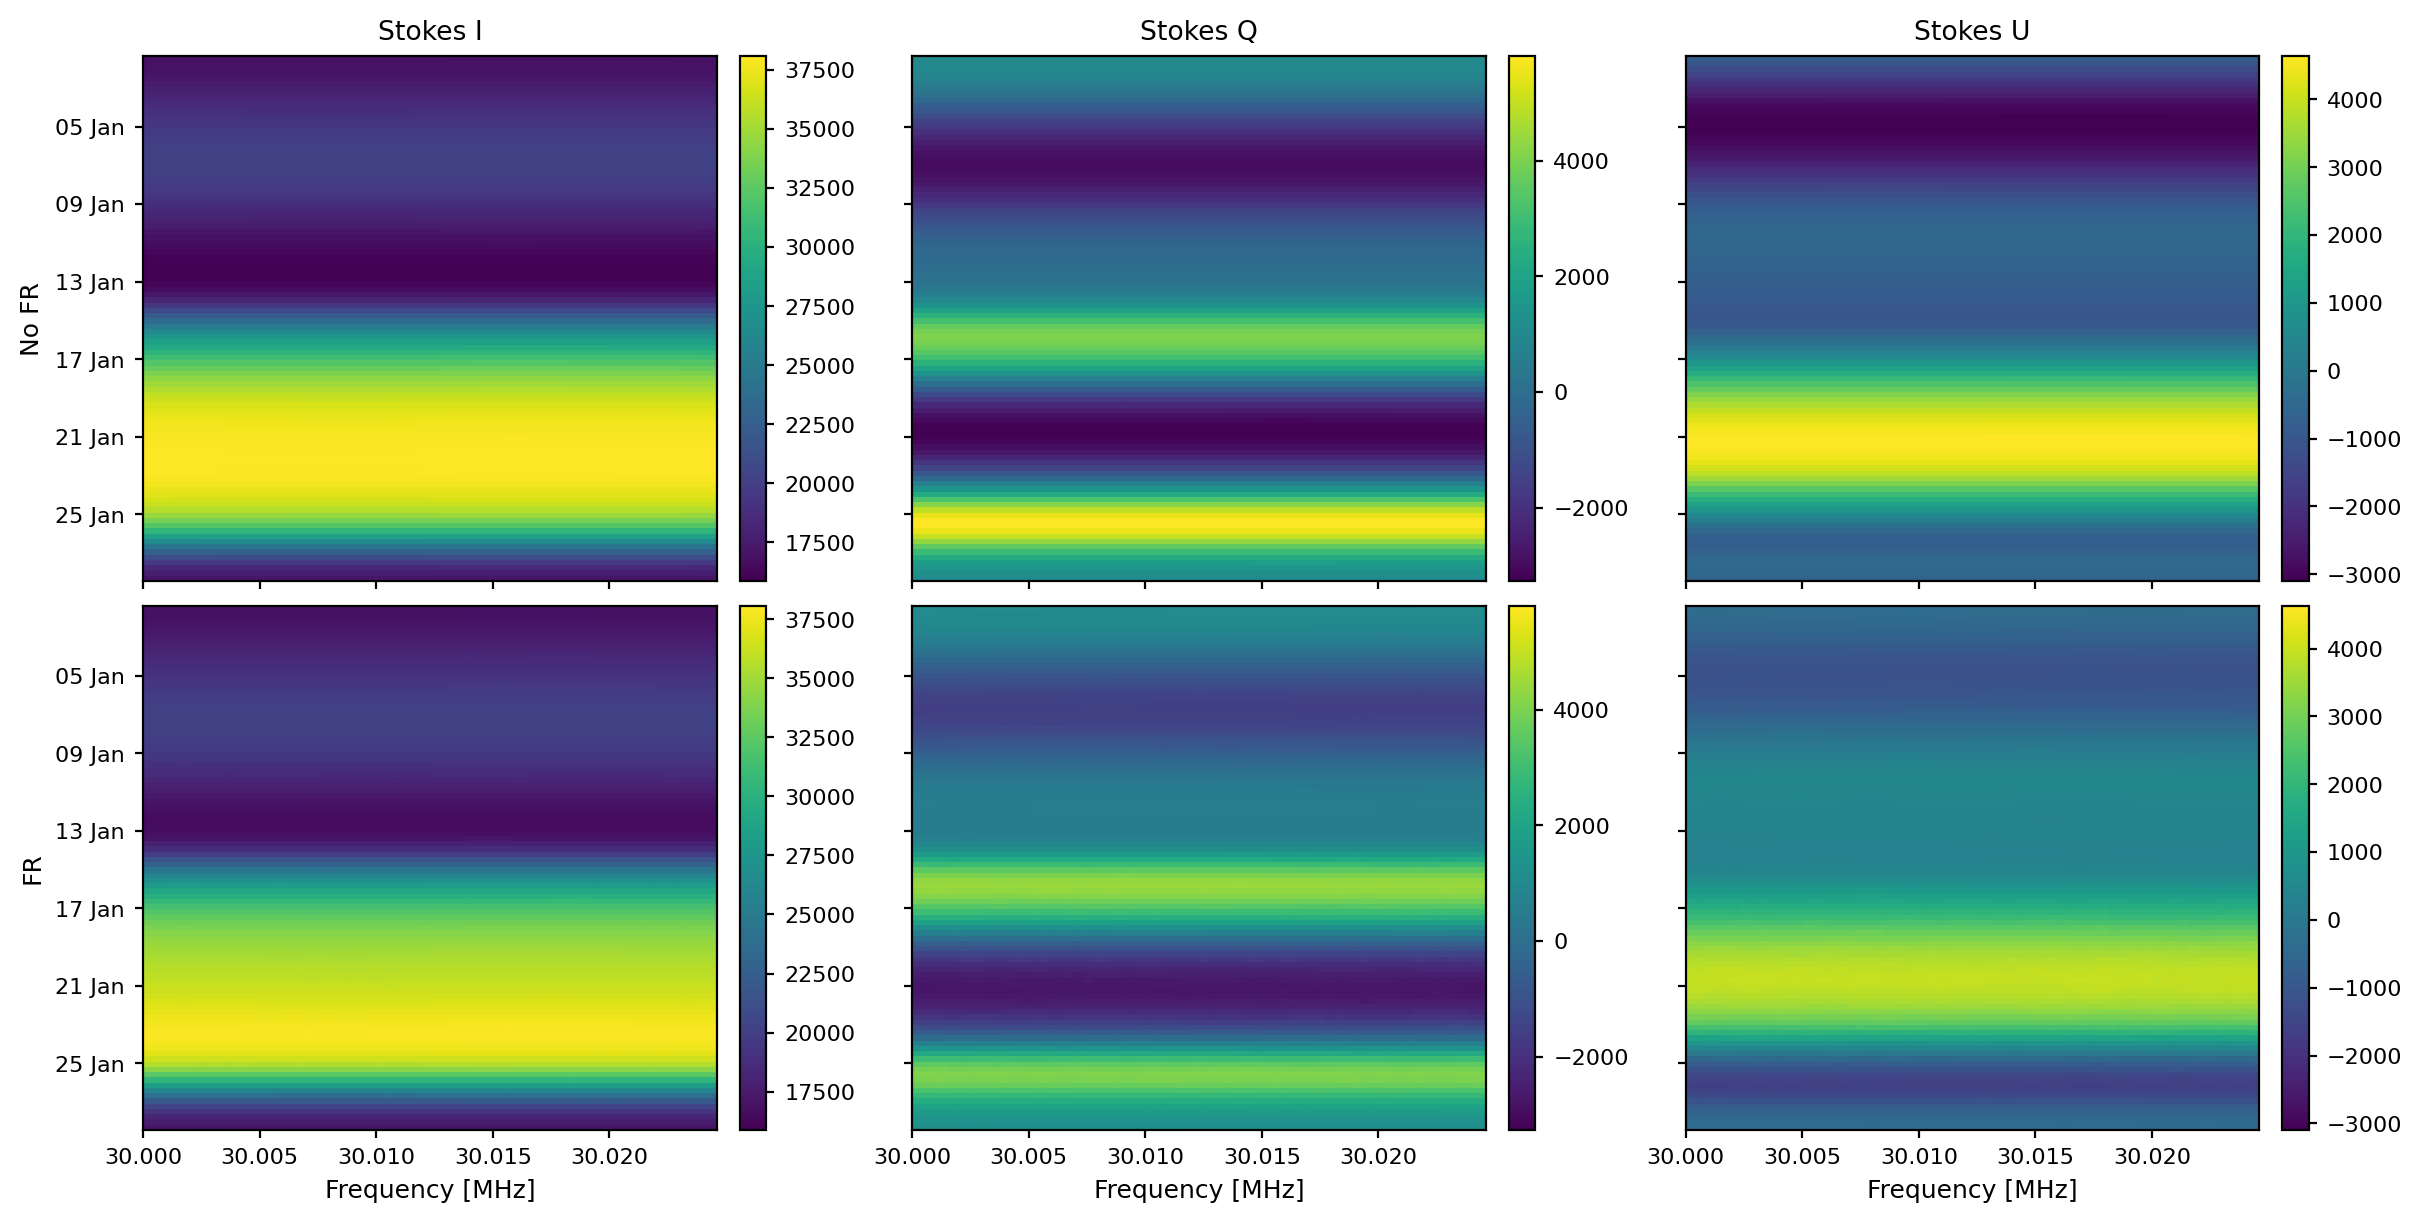

In [2]:
d = sims[30]
fz = d["freqs_zoom"]
extent = [fz[0], fz[-1], mdates.date2num(times_dt[-1]), mdates.date2num(times_dt[0])]

stokes = ["I", "Q", "U"]
rows = ["noFR", "FR"]
row_labels = ["No FR", "FR"]

fig, axs = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)

for col, s in enumerate(stokes):
    arr_noFR = d[f"p{s}_noFR_zoom"]
    arr_FR = d[f"p{s}_FR_zoom"]
    vmin = min(arr_noFR.min(), arr_FR.min())
    vmax = max(arr_noFR.max(), arr_FR.max())
    for row, (tag, label) in enumerate(zip(rows, row_labels)):
        ax = axs[row, col]
        arr = arr_noFR if tag == "noFR" else arr_FR
        im = ax.imshow(arr, aspect="auto", extent=extent, vmin=vmin, vmax=vmax)
        ax.yaxis_date()
        ax.yaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        if row == 0:
            ax.set_title(f"Stokes {s}")
        if col == 0:
            ax.set_ylabel(label)
        else:
            ax.set_yticklabels([])
        if row == 1:
            ax.set_xlabel("Frequency [MHz]")
        else:
            ax.set_xticklabels([])

plt.show()

## Plot 2 — Delay Spectrum Q & U at 10, 30, 50 MHz

Single galaxy-up snapshot (time index 81) at all three frequencies.

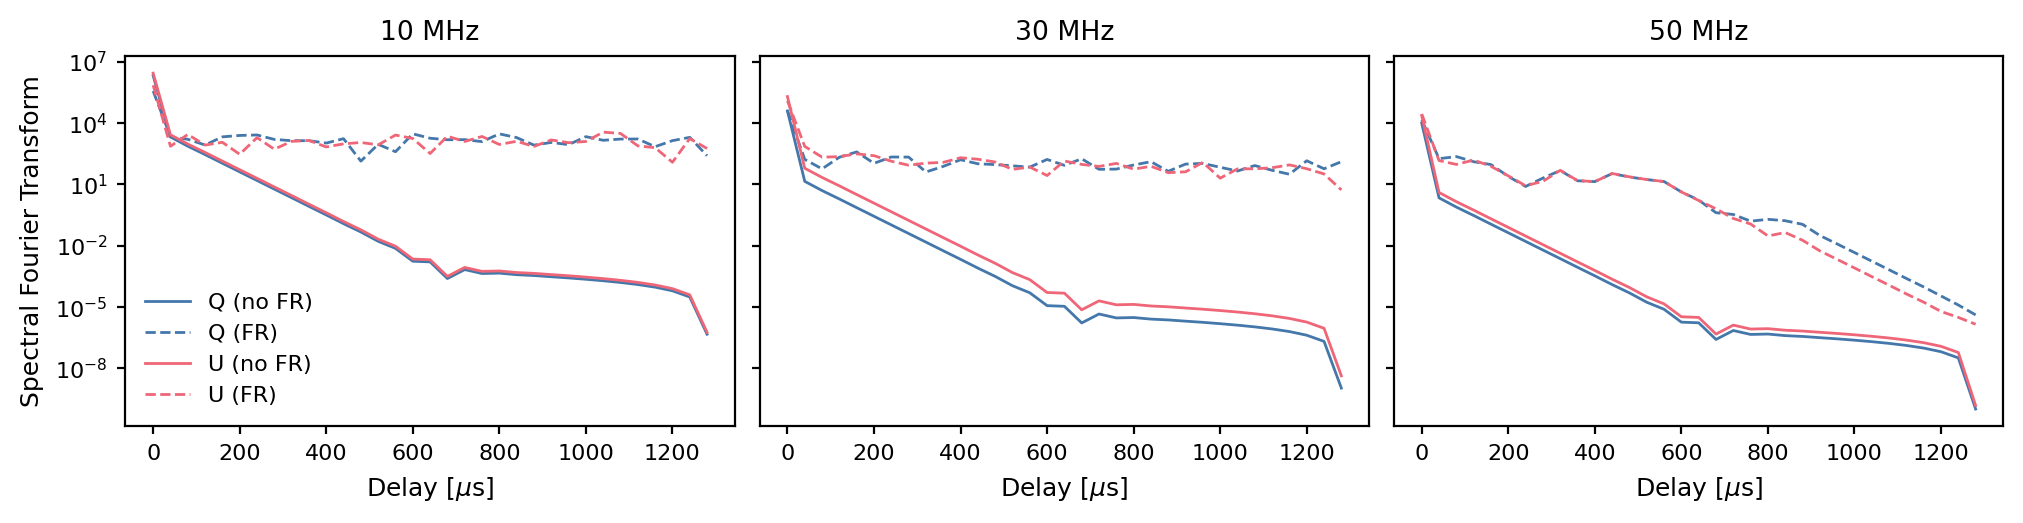

In [9]:
I_GAL = 81  # common time index for all three frequencies

# Load full-resolution FR results (computed at 10001 freqs, not decimated)
fullres = dict(np.load(RES_DIR / "fr_fullres_t81.npz"))

fig, axs = plt.subplots(1, 3, figsize=(10, 2.5), constrained_layout=True,
                         sharey=True)

for i, freq in enumerate([10, 30, 50]):
    ax = axs[i]
    d = sims[freq]
    fz = d["freqs_zoom"]
    df = fz[1] - fz[0]
    tau = np.fft.rfftfreq(64, d=df)

    Q_noFR = d["pQ_noFR_zoom"][I_GAL]
    U_noFR = d["pU_noFR_zoom"][I_GAL]
    Q_FR = fullres[f"pQ_FR_zoom_{freq}"]
    U_FR = fullres[f"pU_FR_zoom_{freq}"]

    ft_Q_noFR = np.abs(np.fft.rfft(Q_noFR))
    ft_Q_FR = np.abs(np.fft.rfft(Q_FR))
    ft_U_noFR = np.abs(np.fft.rfft(U_noFR))
    ft_U_FR = np.abs(np.fft.rfft(U_FR))

    ax.plot(tau, ft_Q_noFR, color=BLUE, ls="-", lw=1, label="Q (no FR)")
    ax.plot(tau, ft_Q_FR, color=BLUE, ls="--", lw=1, label="Q (FR)")
    ax.plot(tau, ft_U_noFR, color=RED, ls="-", lw=1, label="U (no FR)")
    ax.plot(tau, ft_U_FR, color=RED, ls="--", lw=1, label="U (FR)")

    ax.set_yscale("log")
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=range(2, 10),
                                           numticks=12))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.set_title(f"{freq} MHz")
    ax.set_xlabel(r"Delay [$\mu$s]")

axs[0].set_ylabel("Spectral Fourier Transform")
axs[0].legend(frameon=False, loc="best")
plt.show()

### Note: Comparison with `wmap_one.ipynb`

The no-FR delay spectrum drops off much faster here than in `wmap_one.ipynb`. Three differences between the pipelines explain this:

1. **Spectrometer convolution** (dominant effect on FFT shape): `wmap_one` computes visibilities directly at 64 zoom frequencies — no spectrometer response applied. `faraday_sims` computes at ~10,000 raw frequencies and convolves with the spectrometer narrow-bin response to produce 64 zoom bins. This convolution smooths the already-smooth no-FR power-law spectrum, suppressing high-delay modes by orders of magnitude. The FR signal persists because its Faraday oscillations have structure at the zoom-bin scale.

2. **Sky model** (affects amplitudes, not shape): `wmap_one` scales all of I/Q/U from WMAP 23 GHz with a single spectral index β = −2.5. `faraday_sims` uses Haslam at 50 MHz for I (β = −2.55) and WMAP for Q/U (β = −2.8), giving ~4.7× lower pQ amplitudes.

3. **Time step** (minor): Different sky orientations change pQ amplitude but not the spectral shape.

The plot below demonstrates difference #1 by comparing the convolved zoom-bin data (what the spectrometer actually measures) against the raw spectrum sampled at zoom-bin centers (what `wmap_one` effectively computes).

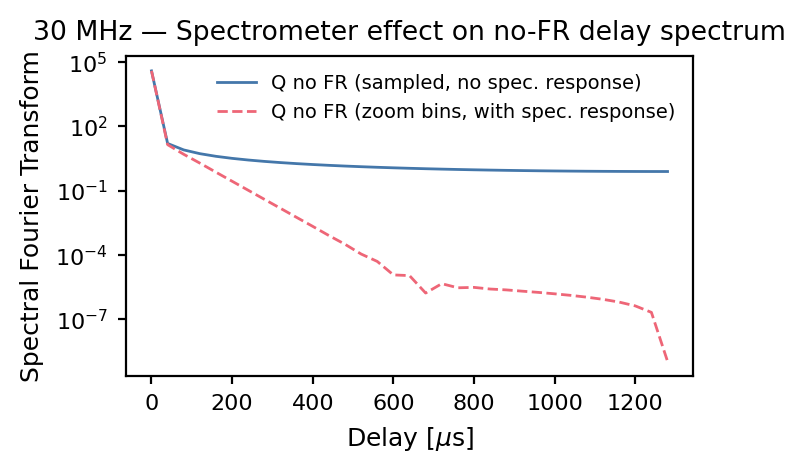

In [4]:
from scipy.interpolate import interp1d

d = sims[30]
fz = d["freqs_zoom"]
df = fz[1] - fz[0]
tau = np.fft.rfftfreq(64, d=df)

# Convolved zoom-bin data (what the spectrometer measures)
Q_zoom = d["pQ_noFR_zoom"][I_GAL]
# Raw spectrum sampled at zoom centers (no spectrometer response)
Q_raw = d["pQ_noFR_raw"][I_GAL]
freqs_raw = d["freqs_narrow_noFR"]
Q_sampled = interp1d(freqs_raw, Q_raw)(fz)

ft_zoom = np.abs(np.fft.rfft(Q_zoom))
ft_samp = np.abs(np.fft.rfft(Q_sampled))

fig, ax = plt.subplots(figsize=(3.45, 2.25), constrained_layout=True)
ax.plot(tau, ft_samp, color=BLUE, ls="-", lw=1,
        label="Q no FR (sampled, no spec. response)")
ax.plot(tau, ft_zoom, color=RED, ls="--", lw=1,
        label="Q no FR (zoom bins, with spec. response)")
ax.set_yscale("log")
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=range(2, 10),
                                       numticks=12))
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_xlabel(r"Delay [$\mu$s]")
ax.set_ylabel("Spectral Fourier Transform")
ax.set_title("30 MHz — Spectrometer effect on no-FR delay spectrum")
ax.legend(frameon=False, fontsize=7)
plt.show()

### Delay Spectrum with Radiometer Noise

Radiometer noise σ = T_sys / √(Δt · Δf) added independently per zoom bin.
T_sys ≈ Stokes I (sky-dominated). The noise is white in frequency, producing
a flat floor in delay space. One sidereal day ≈ 655.7 hours ≈ 2.36 × 10⁶ s.

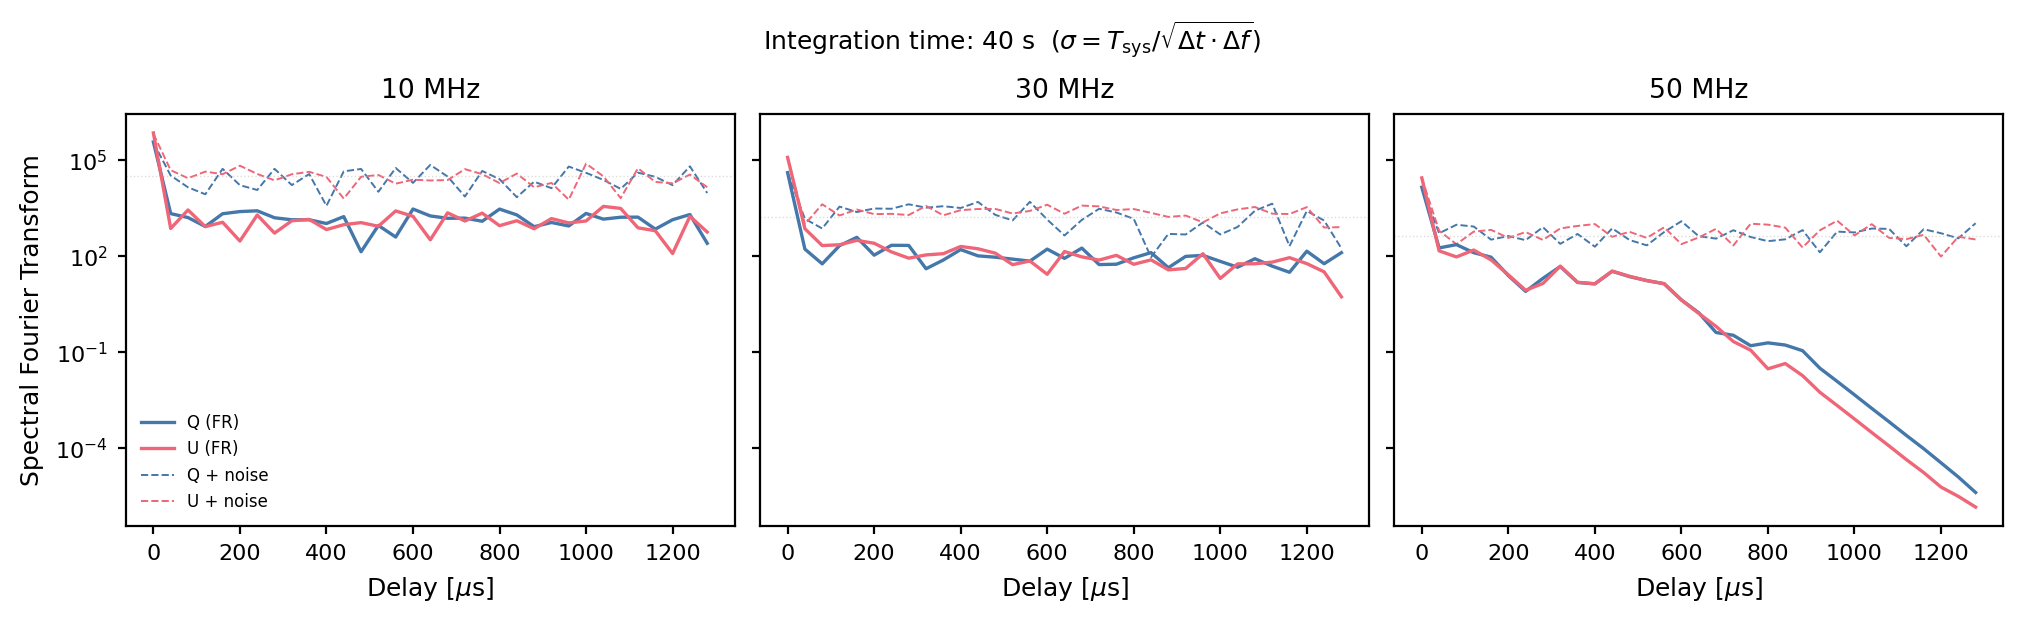

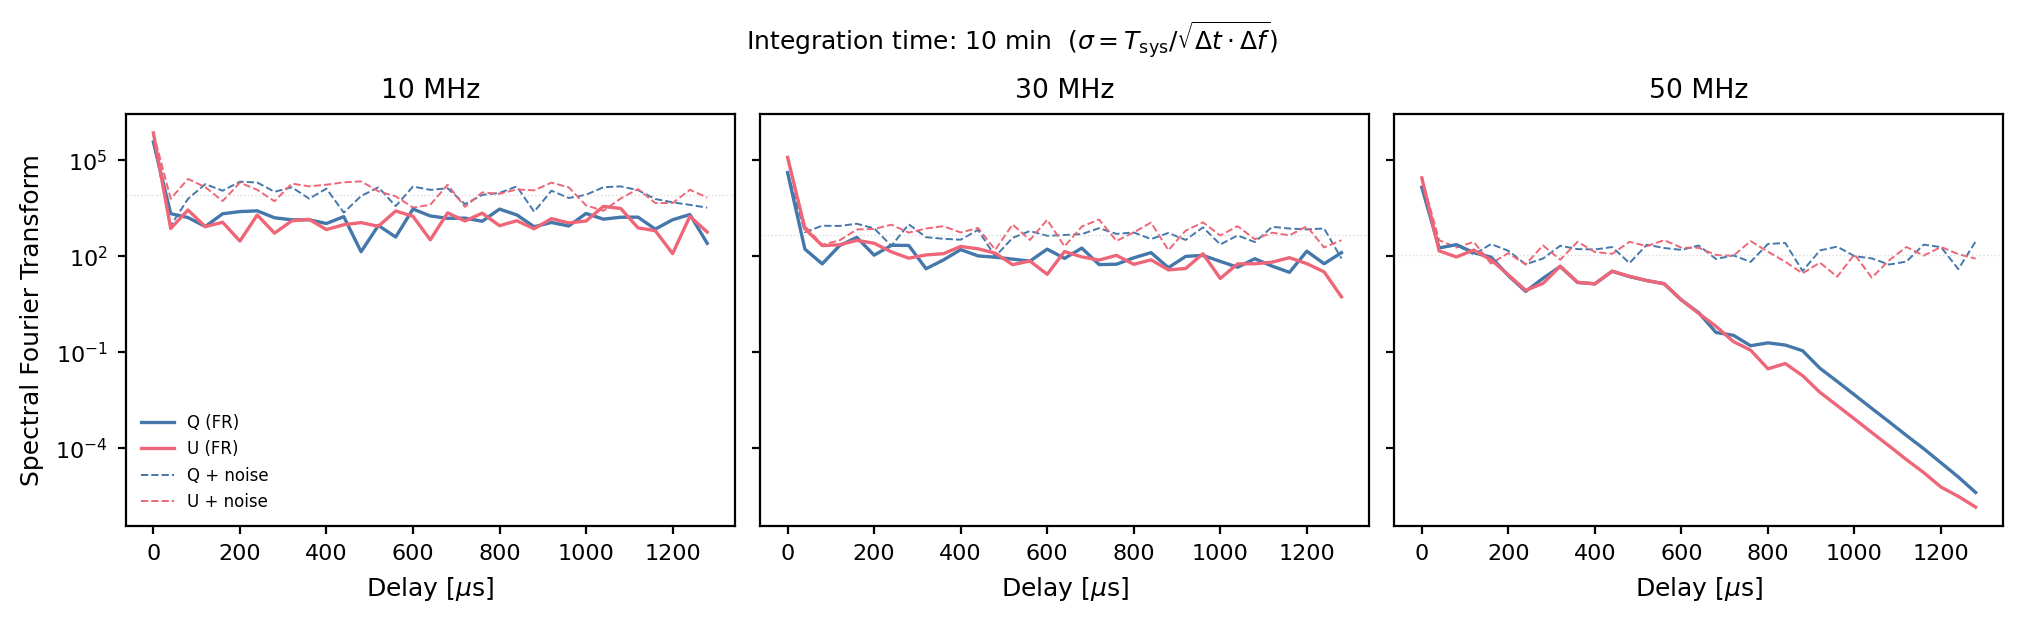

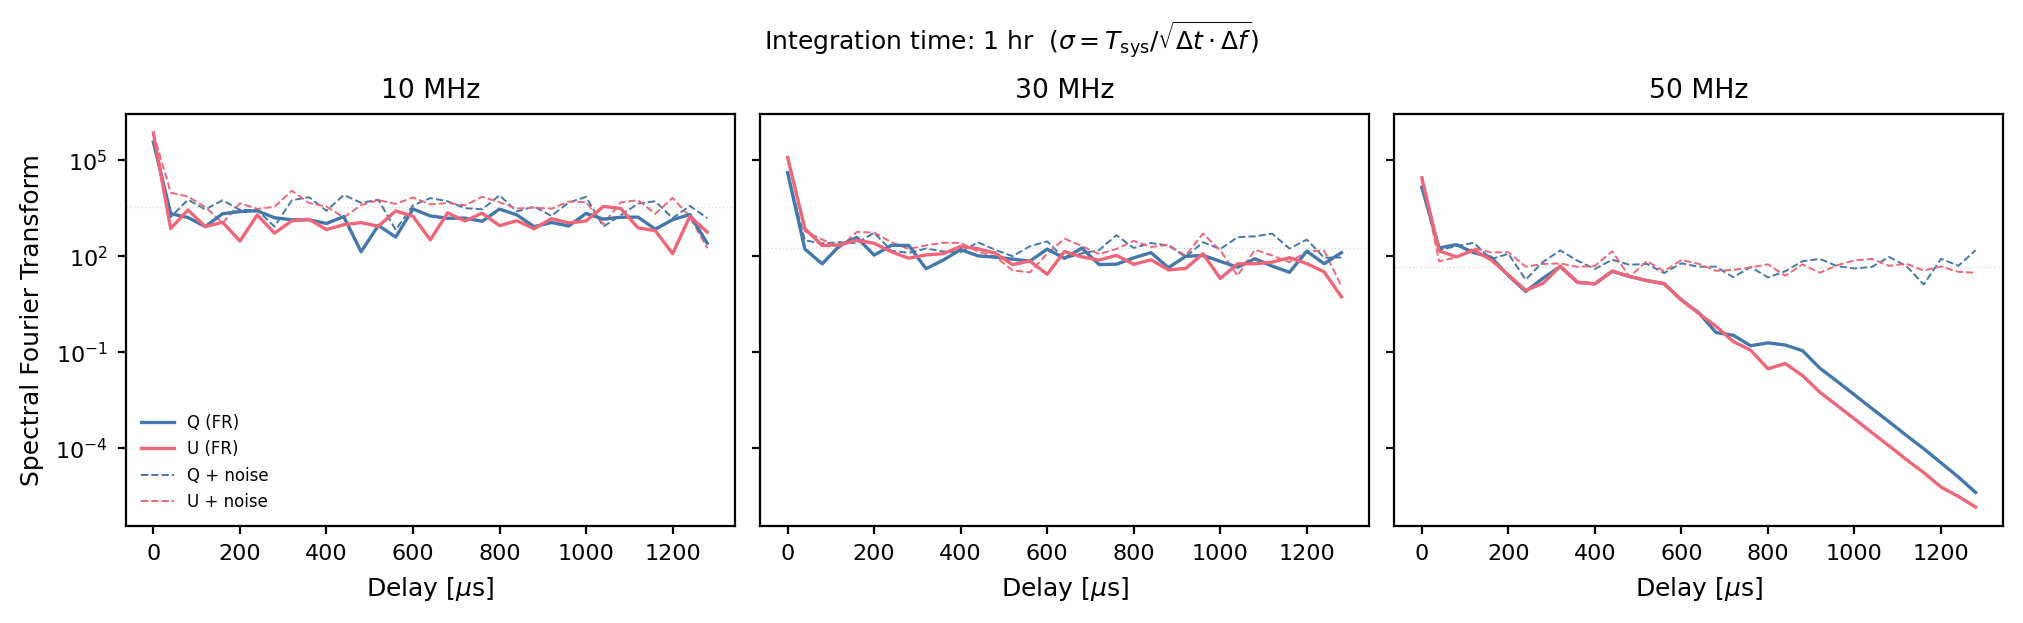

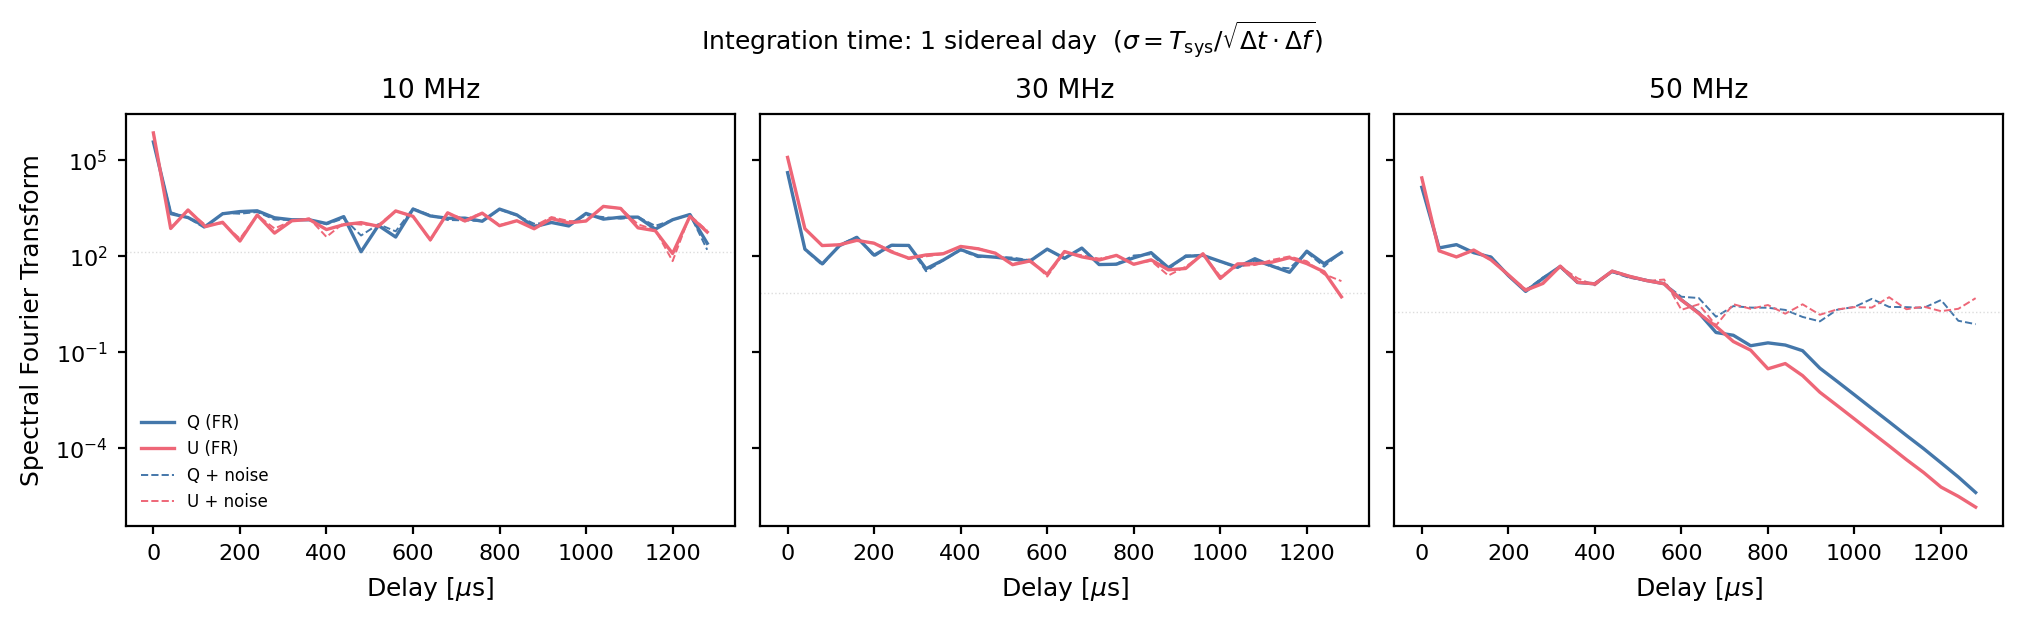

In [10]:
GREY = "#BBBBBB"
SIDEREAL_DAY = 655.72 * 3600  # seconds
integration_times = [
    (40, "40 s"),
    (10 * 60, "10 min"),
    (3600, "1 hr"),
    (SIDEREAL_DAY, "1 sidereal day"),
]
rng = np.random.default_rng(42)

for dt_s, dt_label in integration_times:
    fig, axs = plt.subplots(1, 3, figsize=(10, 3), constrained_layout=True,
                             sharey=True)
    for i, freq in enumerate([10, 30, 50]):
        ax = axs[i]
        d = sims[freq]
        fz = d["freqs_zoom"]
        df_mhz = fz[1] - fz[0]
        df_hz = df_mhz * 1e6
        tau = np.fft.rfftfreq(64, d=df_mhz)

        Q_FR = fullres[f"pQ_FR_zoom_{freq}"]
        U_FR = fullres[f"pU_FR_zoom_{freq}"]
        T_sys = fullres[f"pI_FR_zoom_{freq}"].mean()

        # Signal (no noise)
        ft_Q = np.abs(np.fft.rfft(Q_FR))
        ft_U = np.abs(np.fft.rfft(U_FR))
        ax.plot(tau, ft_Q, color=BLUE, ls="-", lw=1.2,
                label="Q (FR)", zorder=5)
        ax.plot(tau, ft_U, color=RED, ls="-", lw=1.2,
                label="U (FR)", zorder=5)

        # Signal + noise
        sigma = T_sys / np.sqrt(dt_s * df_hz)
        noise_Q = rng.normal(0, sigma, 64)
        noise_U = rng.normal(0, sigma, 64)
        ft_Qn = np.abs(np.fft.rfft(Q_FR + noise_Q))
        ft_Un = np.abs(np.fft.rfft(U_FR + noise_U))
        ax.plot(tau, ft_Qn, color=BLUE, ls="--", lw=0.7,
                label="Q + noise")
        ax.plot(tau, ft_Un, color=RED, ls="--", lw=0.7,
                label="U + noise")

        # Analytic noise floor
        noise_floor = sigma * np.sqrt(64 / 2)
        ax.axhline(noise_floor, color=GREY, ls=":", lw=0.5, alpha=0.5)

        ax.set_yscale("log")
        ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
        ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=range(2, 10),
                                               numticks=12))
        ax.yaxis.set_minor_formatter(NullFormatter())
        ax.set_title(f"{freq} MHz")
        ax.set_xlabel(r"Delay [$\mu$s]")

    axs[0].set_ylabel("Spectral Fourier Transform")
    axs[0].legend(frameon=False, fontsize=6, loc="best")
    fig.suptitle(f"Integration time: {dt_label}  "
                 r"($\sigma = T_\mathrm{sys} / \sqrt{\Delta t \cdot \Delta f}$)",
                 fontsize=9)
    plt.show()

## Plot 3 — Delay Waterfall at 30 MHz

Delay vs time for no-FR (top) and FR (bottom).

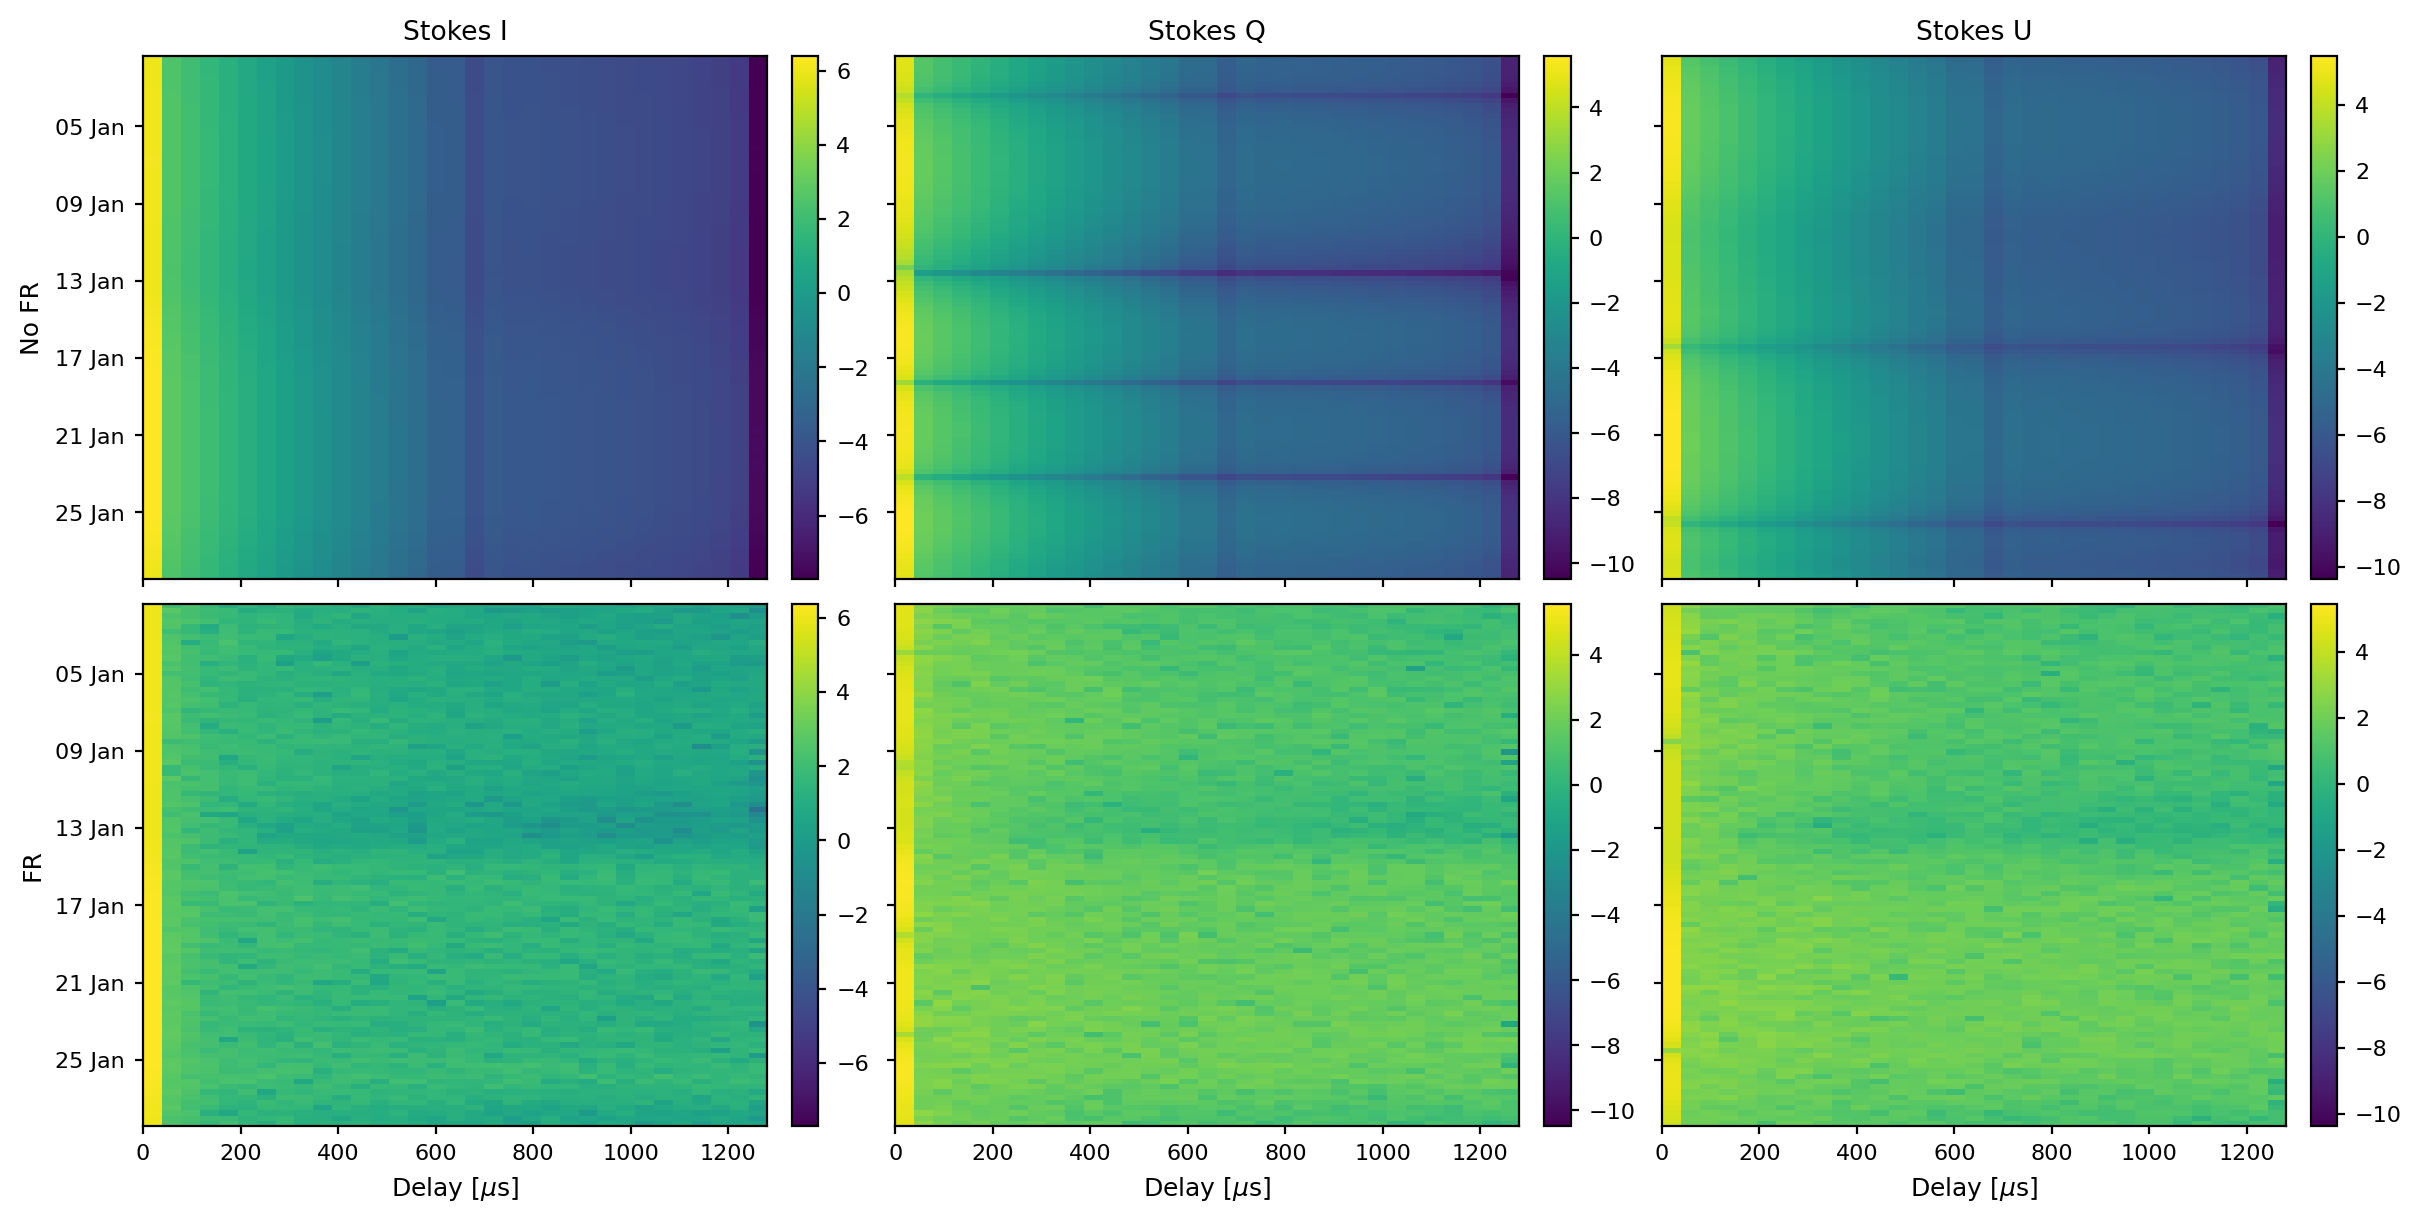

In [6]:
d = sims[30]
fz = d["freqs_zoom"]
df = fz[1] - fz[0]
tau = np.fft.rfftfreq(64, d=df)
extent_dly = [tau[0], tau[-1], mdates.date2num(times_dt[-1]),
              mdates.date2num(times_dt[0])]

fig, axs = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)

for col, s in enumerate(stokes):
    arr_noFR = d[f"p{s}_noFR_zoom"]
    arr_FR = d[f"p{s}_FR_zoom"]
    ft_noFR = np.log10(np.abs(np.fft.rfft(arr_noFR, axis=1)))
    ft_FR = np.log10(np.abs(np.fft.rfft(arr_FR, axis=1)))
    vmin = min(ft_noFR.min(), ft_FR.min())
    vmax = max(ft_noFR.max(), ft_FR.max())
    for row, (ft, label) in enumerate(zip([ft_noFR, ft_FR], row_labels)):
        ax = axs[row, col]
        im = ax.imshow(ft, aspect="auto", extent=extent_dly,
                       vmin=vmin, vmax=vmax)
        ax.yaxis_date()
        ax.yaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        if row == 0:
            ax.set_title(f"Stokes {s}")
        if col == 0:
            ax.set_ylabel(label)
        else:
            ax.set_yticklabels([])
        if row == 1:
            ax.set_xlabel(r"Delay [$\mu$s]")
        else:
            ax.set_xticklabels([])

plt.show()

## Plot 4 — Wide Bin vs Narrow Bin at 10, 30, 50 MHz

Galaxy-up snapshot comparing zoom-bin spectra to the single wide-bin value.

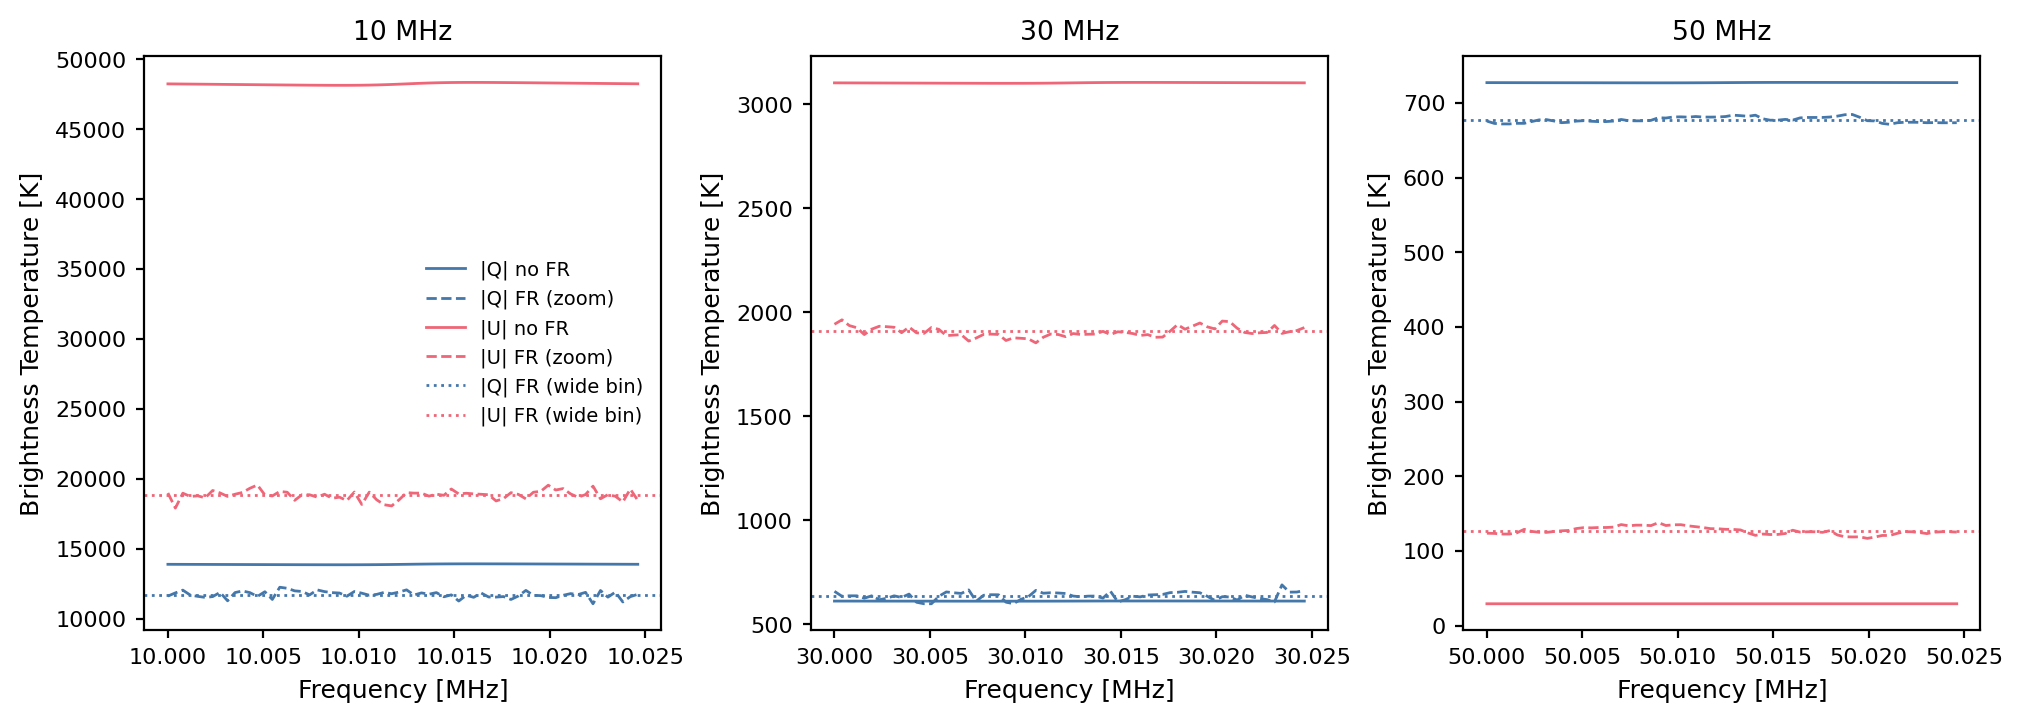

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3.5), constrained_layout=True)

for i, freq in enumerate([10, 30, 50]):
    ax = axs[i]
    d = sims[freq]
    fz = d["freqs_zoom"]
    ig = int(d["i_gal"])

    # Zoom-bin spectra (absolute values)
    ax.plot(fz, np.abs(d["pQ_noFR_zoom"][ig]), color=BLUE, ls="-", lw=1,
            label="|Q| no FR")
    ax.plot(fz, np.abs(d["pQ_FR_zoom"][ig]), color=BLUE, ls="--", lw=1,
            label="|Q| FR (zoom)")
    ax.plot(fz, np.abs(d["pU_noFR_zoom"][ig]), color=RED, ls="-", lw=1,
            label="|U| no FR")
    ax.plot(fz, np.abs(d["pU_FR_zoom"][ig]), color=RED, ls="--", lw=1,
            label="|U| FR (zoom)")

    # Wide-bin horizontal lines (center bin = index 32)
    ax.axhline(np.abs(d["pQ_FR_wconv"][0, 32]), color=BLUE, ls=":", lw=1,
               label="|Q| FR (wide bin)")
    ax.axhline(np.abs(d["pU_FR_wconv"][0, 32]), color=RED, ls=":", lw=1,
               label="|U| FR (wide bin)")

    ax.set_title(f"{freq} MHz")
    ax.set_xlabel("Frequency [MHz]")
    ax.set_ylabel("Brightness Temperature [K]")

axs[0].legend(frameon=False, fontsize=7)
plt.show()

## Plot 5 — Polarized Power (Q² + U²): Wide vs Narrow Bin

Same comparison as Plot 4 but combining Q and U into polarized power, since FR just rotates between them.

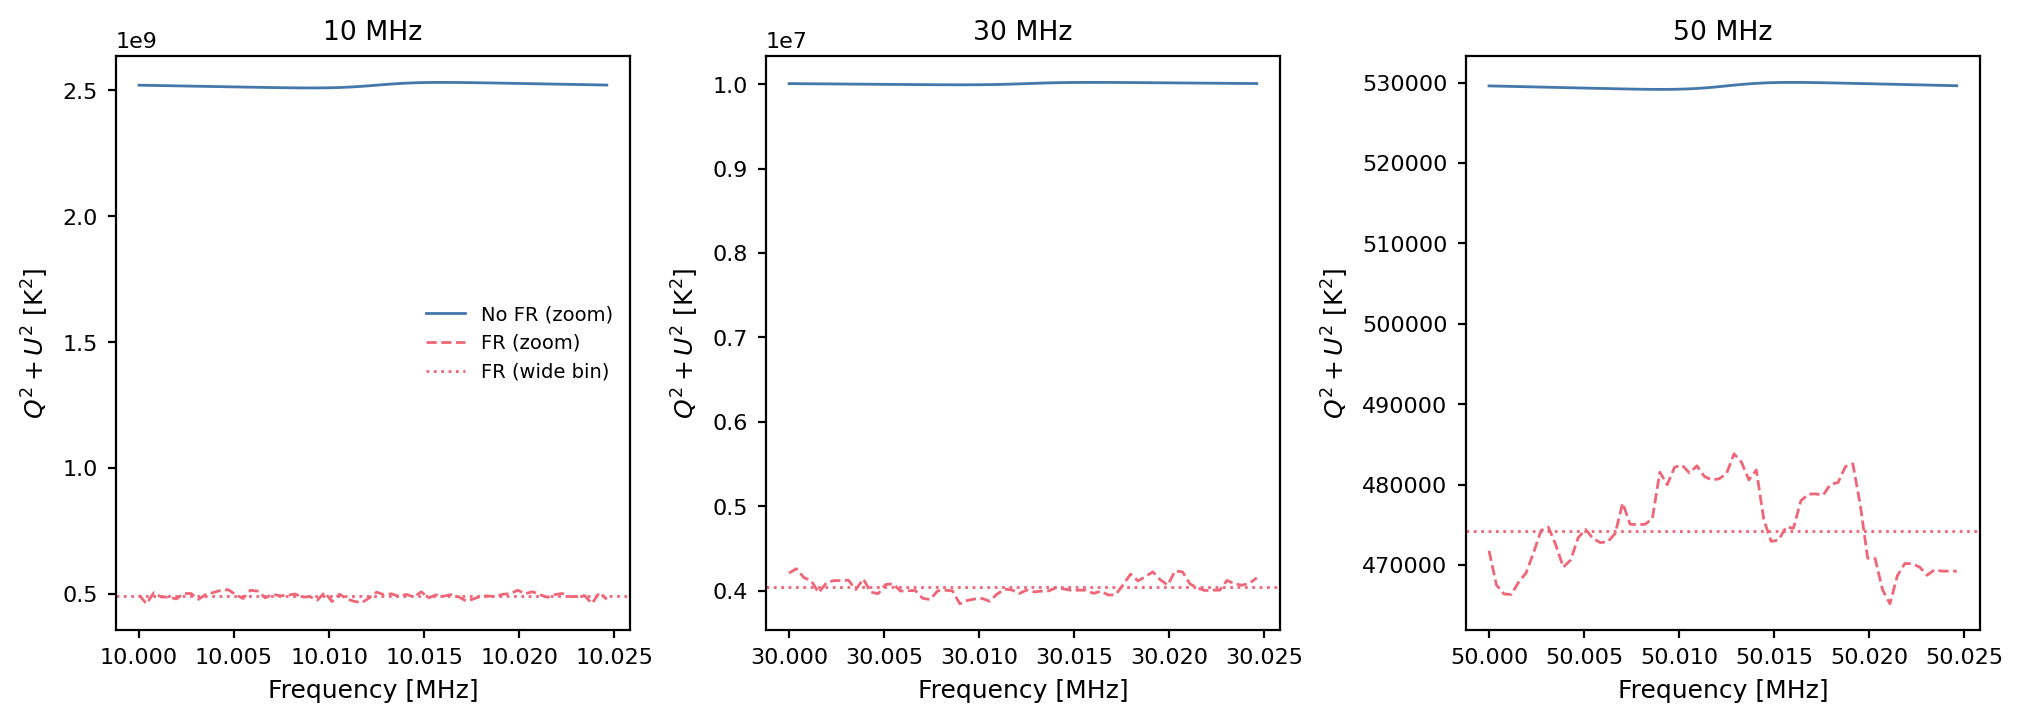

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3.5), constrained_layout=True)

for i, freq in enumerate([10, 30, 50]):
    ax = axs[i]
    d = sims[freq]
    fz = d["freqs_zoom"]
    ig = int(d["i_gal"])

    # Polarized power Q^2 + U^2
    P2_noFR = d["pQ_noFR_zoom"][ig]**2 + d["pU_noFR_zoom"][ig]**2
    P2_FR = d["pQ_FR_zoom"][ig]**2 + d["pU_FR_zoom"][ig]**2
    P2_wconv = d["pQ_FR_wconv"][0, 32]**2 + d["pU_FR_wconv"][0, 32]**2

    ax.plot(fz, P2_noFR, color=BLUE, ls="-", lw=1, label="No FR (zoom)")
    ax.plot(fz, P2_FR, color=RED, ls="--", lw=1, label="FR (zoom)")
    ax.axhline(P2_wconv, color=RED, ls=":", lw=1, label="FR (wide bin)")

    ax.set_title(f"{freq} MHz")
    ax.set_xlabel("Frequency [MHz]")
    ax.set_ylabel(r"$Q^2 + U^2$ [K$^2$]")

axs[0].legend(frameon=False, fontsize=7)
plt.show()